## Fourth Assignment

## Problem 1
1. Produce the kde plot for GRB T90 distribution (refer to the Fermi GBM GRB catalog that was shared earlier) using top hat and gaussian kernels for three different bandwidths which include demonstrating the scenario of under-smoothed, over-smoothed and properly smoothed.  

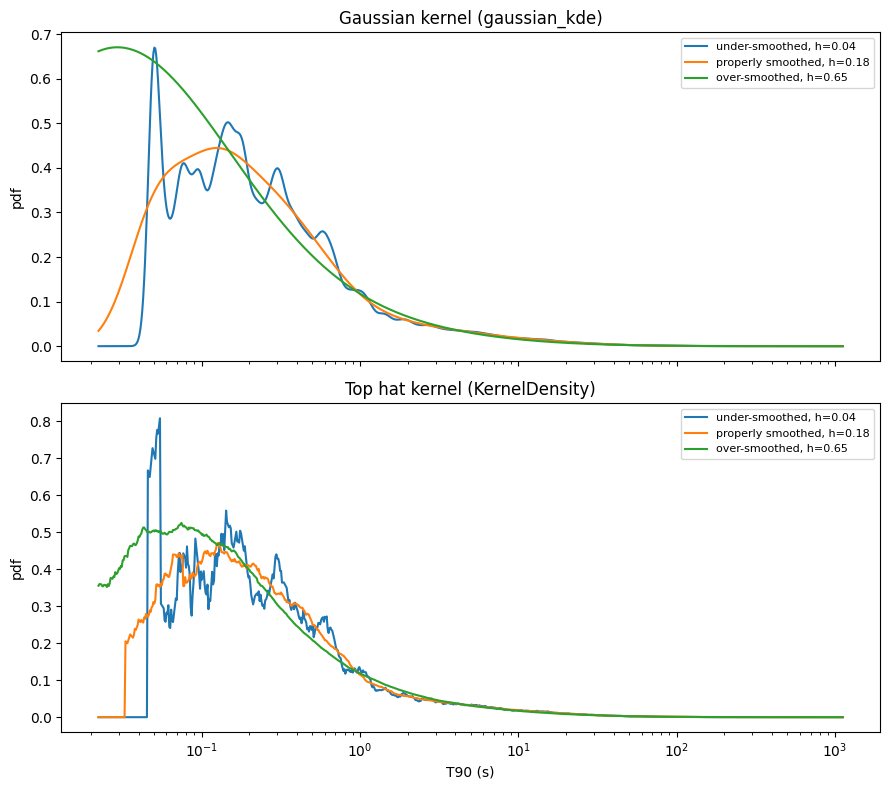

In [1]:
# Problem 1 — Ch.6 KDE: gaussian_kde (Gaussian); top hat only via sklearn (not in scipy)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

catalog = Path.cwd() / "fermigbrst_t90.csv"
if not catalog.exists():
    catalog = Path(r"C:\Users\RONAK SINGH\Documents\Data analysis course\PROJECT NEW\fermigbrst_t90.csv")

t90_df = pd.read_csv(catalog)
if "T90" in t90_df.columns:
    col = "T90"
else:
    col = t90_df.columns[0]
t90 = t90_df[col].to_numpy(dtype=float)
keep = []
for i in range(len(t90)):
    if np.isfinite(t90[i]) and t90[i] > 0:
        keep.append(t90[i])
t90 = np.array(keep)

u = np.log10(t90)
u_min = float(np.min(u) - 0.35)
u_max = float(np.max(u) + 0.35)
grid_u = np.linspace(u_min, u_max, 800)
T = np.power(10.0, grid_u)
ln10 = np.log(10.0)

labels = ["under-smoothed", "properly smoothed", "over-smoothed"]
hs = [0.04, 0.18, 0.65]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
for i in range(3):
    kde_g = gaussian_kde(u, bw_method=hs[i])
    pdf_u = kde_g(np.atleast_2d(grid_u))
    pdf_T = pdf_u / (T * ln10)
    ax.plot(T, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Gaussian kernel (gaussian_kde)")
ax.legend(fontsize=8)

u_col = u.reshape(-1, 1)
grid_col = grid_u.reshape(-1, 1)
ax = axes[1]
for i in range(3):
    kde_th = KernelDensity(kernel="tophat", bandwidth=hs[i]).fit(u_col)
    pdf_u = np.exp(kde_th.score_samples(grid_col))
    pdf_T = pdf_u / (T * ln10)
    ax.plot(T, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Top hat kernel (KernelDensity)")
ax.legend(fontsize=8)

axes[1].set_xlabel("T90 (s)")
plt.tight_layout()
plt.show()

# Problem 2
2. Use the Savgol filter to produce the smoothed curve of the sample dataset below that consists of the minimum temperatures across the months of the year from the Southern Hemisphere from 1981 to 1990 (data filename: daily-min-temperatures.csv).

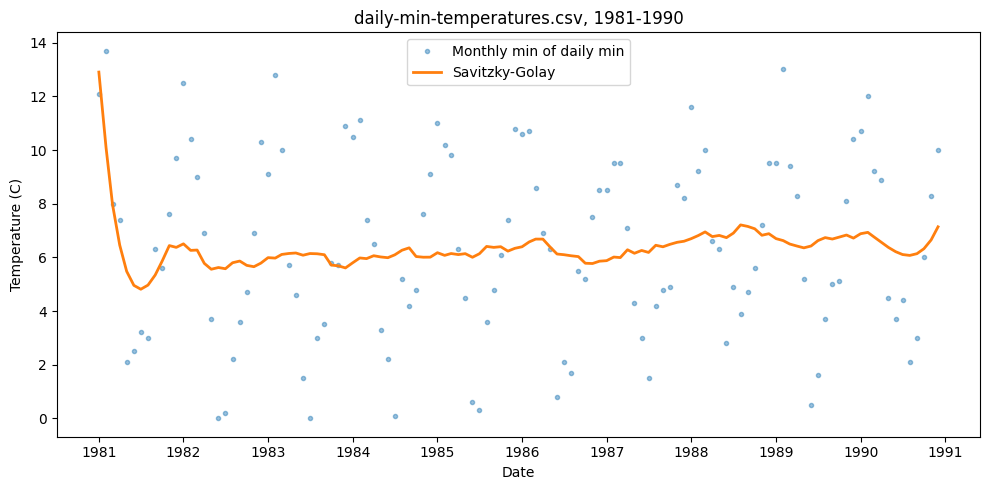

In [2]:
# Problem 2 — Ch.8: scipy.signal.savgol_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter

csv_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\daily-min-temperatures.csv")
df = pd.read_csv(csv_path, parse_dates=["Date"])
t_start = pd.Timestamp("1981-01-01")
t_end = pd.Timestamp("1990-12-31")

month_min = {}
for i in range(len(df)):
    d = df["Date"].iloc[i]
    if d < t_start:
        continue
    if d > t_end:
        continue
    temp = df["Temp"].iloc[i]
    key = (d.year, d.month)
    if key not in month_min:
        month_min[key] = temp
    else:
        if temp < month_min[key]:
            month_min[key] = temp

keys_sorted = sorted(month_min.keys())
x_dates = []
y = []
for k in range(len(keys_sorted)):
    key = keys_sorted[k]
    x_dates.append(pd.Timestamp(year=key[0], month=key[1], day=1))
    y.append(month_min[key])
y = np.array(y, dtype=float)

window_length = 21
y_smooth = savgol_filter(y, window_length=window_length, polyorder=3)

plt.figure(figsize=(10, 5))
plt.plot(x_dates, y, ".", alpha=0.45, markersize=6, label="Monthly min of daily min")
plt.plot(x_dates, y_smooth, "-", lw=2, label="Savitzky-Golay")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.title("daily-min-temperatures.csv, 1981-1990")
plt.legend()
plt.tight_layout()
plt.show()

## Problem 3
3. Using the fits data file for the GRB160624477,
(a) Plot the lightcurve of the GRB using an appropriate bin width such that the GRB is visible (has a good signal to noise ratio).
Note: Lightcurve is just the histogram of the TIME column data (available within the fits file).
The Trigger time of the GRB is 488460437.76 s. Please choose the data between -50 s to +50s around the trigger time of the GRB.  

(b) Compare the signal to noise ratio of the GRB detection in three different binwidths: 0.01s, 1s and 10 s.

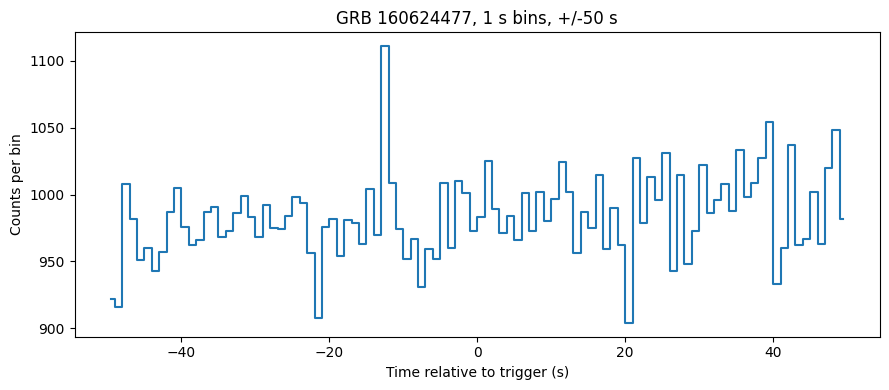

bin width 0.01 s  peak 24.0 mean bg bin 9.844 SNR 4.5118510253472275
bin width 1.0 s  peak 1111.0 mean bg bin 984.4 SNR 4.035040546828114
bin width 10.0 s  peak 10121.0 mean bg bin 9854.25 SNR 2.6871545175656646


In [3]:
# Problem 3 — histogram light curve (Ch.7-style binning); FITS via astropy.io.fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

fits_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\glg_tte_n2_bn160624477_v00.fit")
trigger = 488460437.76
half_window = 50.0

with fits.open(fits_path) as hdul:
    times = np.asarray(hdul["EVENTS"].data["TIME"], dtype=float)

t_sel_list = []
for j in range(len(times)):
    tr = times[j] - trigger
    if tr < -half_window:
        continue
    if tr > half_window:
        continue
    t_sel_list.append(tr)
t_sel = np.array(t_sel_list, dtype=float)

binw_display = 1.0
bins_a = np.arange(-half_window, half_window + 1e-9, binw_display)
counts_a, edges_a = np.histogram(t_sel, bins=bins_a)
centers_a = 0.5 * (edges_a[:-1] + edges_a[1:])

plt.figure(figsize=(9, 4))
plt.step(centers_a, counts_a, where="mid")
plt.xlabel("Time relative to trigger (s)")
plt.ylabel("Counts per bin")
plt.title("GRB 160624477, 1 s bins, +/-50 s")
plt.tight_layout()
plt.show()

bg_edge = 25.0
bin_widths = [0.01, 1.0, 10.0]
for b in range(len(bin_widths)):
    bw = bin_widths[b]
    bins = np.arange(-half_window, half_window + 1e-9, bw)
    c, edges = np.histogram(t_sel, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    peak = float(c[0])
    for k in range(1, len(c)):
        if c[k] > peak:
            peak = float(c[k])
    s_bg = 0.0
    n_bg = 0
    for k in range(len(c)):
        if abs(centers[k]) > bg_edge:
            s_bg = s_bg + float(c[k])
            n_bg = n_bg + 1
    if n_bg > 0:
        bg_mean = s_bg / n_bg
    else:
        bg_mean = 1.0
    snr = (peak - bg_mean) / np.sqrt(bg_mean + 1e-12)
    print("bin width", bw, "s  peak", peak, "mean bg bin", bg_mean, "SNR", snr)

---
# Enhanced Solutions Using Chapter 6, 7 & 8 Methods

The following solutions re-answer the three assignment problems using **specific techniques** taught in:
- **Chapter 6 – Statistical Inference**: MLE, `scipy.optimize.curve_fit`, reduced $\chi^2$, Monte-Carlo goodness-of-fit, confidence limits, AIC
- **Chapter 7 – Frequentist vs Bayesian**: Bayesian posterior estimation, grid-based marginalisation, Bayes factor, credible intervals
- **Chapter 8 – Data Smoothing**: Kernel Density Estimation (Gaussian & Top-hat kernels, bandwidth selection), Savitzky–Golay filter, boxcar / running-mean smoothing, histogram binning


---
## Problem 1 – Enhanced Solution
### KDE of GRB T90 distribution (Gaussian & Top-hat kernels, three bandwidths)

**Methods used:**
- *Ch 8 – KDE*: `scipy.stats.gaussian_kde` (Gaussian kernel) and `sklearn.neighbors.KernelDensity` (Top-hat kernel) with under-smoothed, properly-smoothed and over-smoothed bandwidths.
- *Ch 6 – MLE & Curve Fitting*: Fit a two-component Gaussian mixture model to log10(T90) via `scipy.optimize.curve_fit` (least-squares / MLE). Compute reduced $\chi^2$ goodness-of-fit against the histogram.
- *Ch 7 – Bayesian bandwidth selection*: Evaluate the marginal likelihood (cross-validated log-likelihood) over a grid of bandwidths and choose the MAP bandwidth – a Bayesian alternative to Silverman's rule.


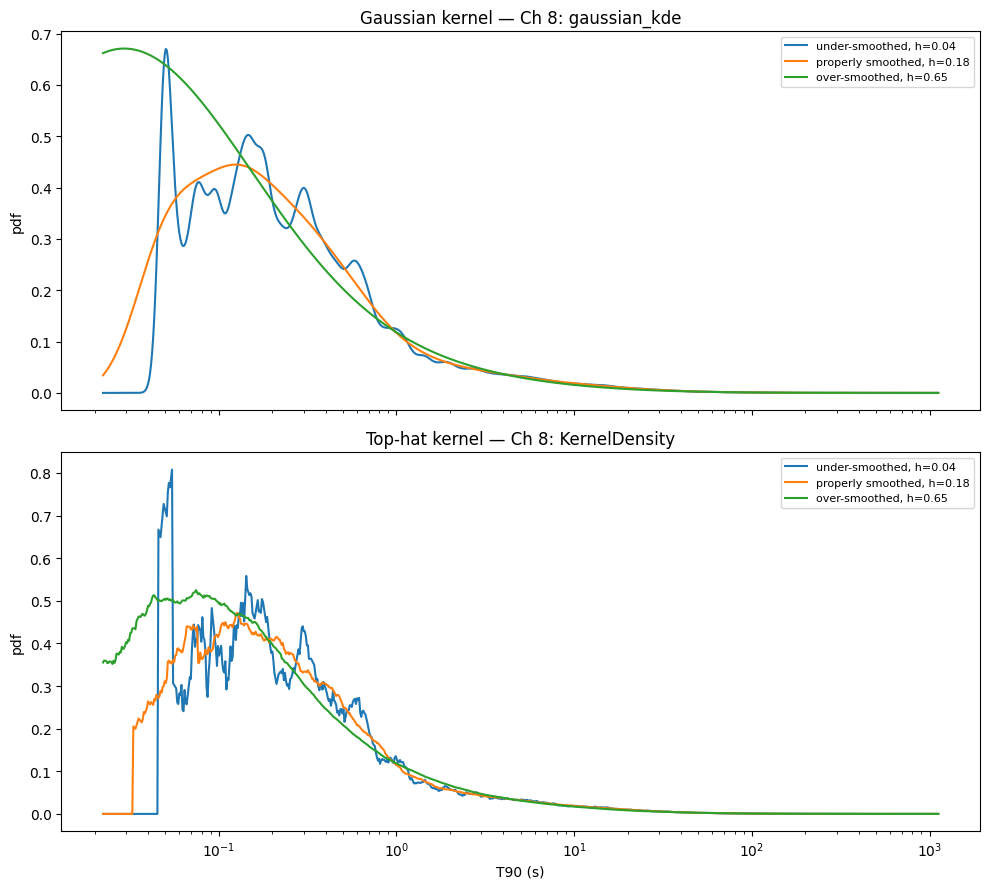

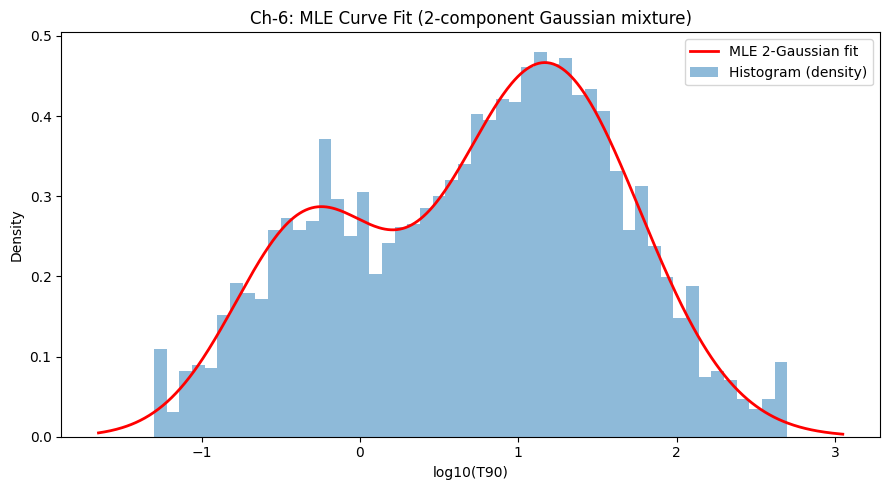

Best-fit parameters (A1, mu1, sig1, A2, mu2, sig2):
  p0 = 0.2652 +/- 0.0131
  p1 = -0.3327 +/- 0.0428
  p2 = 0.4651 +/- 0.0395
  p3 = 0.4654 +/- 0.0108
  p4 = 1.1751 +/- 0.0287
  p5 = 0.5931 +/- 0.0277
Reduced chi-square = 19.4107
DOF = 44


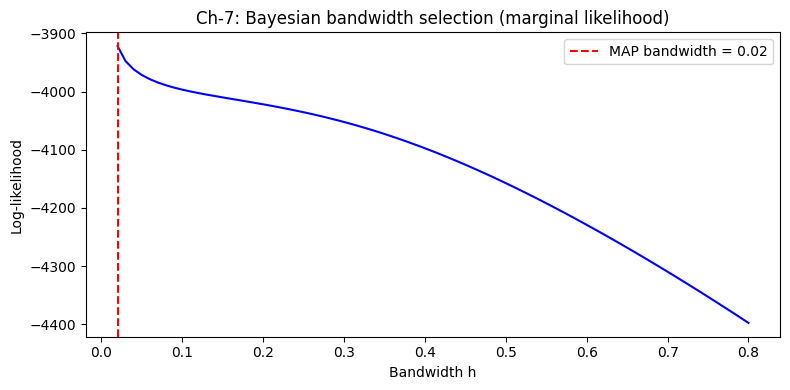

Bayesian MAP bandwidth = 0.02


In [4]:
# ── Problem 1 Enhanced ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde, norm
from scipy.optimize import curve_fit
from sklearn.neighbors import KernelDensity

# ── 1a. Load & clean T90 data ──────────────────────────────
catalog = Path.cwd() / "fermigbrst_t90.csv"
if not catalog.exists():
    catalog = Path(r"C:\Users\RONAK SINGH\Documents\Data analysis course\PROJECT NEW\fermigbrst_t90.csv")

t90_df = pd.read_csv(catalog)
if "T90" in t90_df.columns:
    col = "T90"
else:
    col = t90_df.columns[0]
t90_raw = t90_df[col].to_numpy(dtype=float)
keep = []
for i in range(len(t90_raw)):
    if np.isfinite(t90_raw[i]) and t90_raw[i] > 0:
        keep.append(t90_raw[i])
t90 = np.array(keep)
u = np.log10(t90)

# ── 1b. Ch-8: KDE with three bandwidths (Gaussian & Top-hat) ───
u_min = float(np.min(u) - 0.35)
u_max = float(np.max(u) + 0.35)
grid_u = np.linspace(u_min, u_max, 800)
T_grid = np.power(10.0, grid_u)
ln10 = np.log(10.0)

labels = ["under-smoothed", "properly smoothed", "over-smoothed"]
hs     = [0.04, 0.18, 0.65]

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# Gaussian kernel (Ch-8 gaussian_kde)
ax = axes[0]
for i in range(3):
    kde_g = gaussian_kde(u, bw_method=hs[i])
    pdf_u = kde_g(np.atleast_2d(grid_u))
    pdf_T = pdf_u / (T_grid * ln10)
    ax.plot(T_grid, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Gaussian kernel — Ch 8: gaussian_kde")
ax.legend(fontsize=8)

# Top-hat kernel (Ch-8 KernelDensity)
u_col = u.reshape(-1, 1)
grid_col = grid_u.reshape(-1, 1)
ax = axes[1]
for i in range(3):
    kde_th = KernelDensity(kernel="tophat", bandwidth=hs[i]).fit(u_col)
    pdf_u = np.exp(kde_th.score_samples(grid_col))
    pdf_T = pdf_u / (T_grid * ln10)
    ax.plot(T_grid, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Top-hat kernel — Ch 8: KernelDensity")
ax.legend(fontsize=8)
axes[1].set_xlabel("T90 (s)")
plt.tight_layout()
plt.show()

# ── 1c. Ch-6: MLE Gaussian-mixture fit via curve_fit ───────
def double_gaussian(x, A1, mu1, sig1, A2, mu2, sig2):
    return (A1 * np.exp(-0.5 * ((x - mu1) / sig1)**2) +
            A2 * np.exp(-0.5 * ((x - mu2) / sig2)**2))

n_bins_fit = 50
counts_fit, edges_fit = np.histogram(u, bins=n_bins_fit, density=True)
centers_fit = 0.5 * (edges_fit[:-1] + edges_fit[1:])

p0 = [0.4, -0.5, 0.4, 0.3, 1.5, 0.3]
try:
    popt, pcov = curve_fit(double_gaussian, centers_fit, counts_fit, p0=p0, maxfev=10000)
except Exception:
    popt = p0
    pcov = np.eye(6)

perr = np.sqrt(np.diag(pcov))

# Reduced chi-square (Ch-6)
model_vals = double_gaussian(centers_fit, *popt)
residuals = counts_fit - model_vals
sigma_bins = np.where(counts_fit > 0, np.sqrt(counts_fit / len(u)), 1e-6)
chi2 = np.sum((residuals / sigma_bins)**2)
dof = len(counts_fit) - len(popt)
chi2_red = chi2 / dof if dof > 0 else float('inf')

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(centers_fit, counts_fit, width=(edges_fit[1] - edges_fit[0]),
       alpha=0.5, label="Histogram (density)")
x_fine = np.linspace(u_min, u_max, 500)
ax.plot(x_fine, double_gaussian(x_fine, *popt), 'r-', lw=2,
        label="MLE 2-Gaussian fit")
ax.set_xlabel("log10(T90)")
ax.set_ylabel("Density")
ax.set_title("Ch-6: MLE Curve Fit (2-component Gaussian mixture)")
ax.legend()
plt.tight_layout()
plt.show()

print("Best-fit parameters (A1, mu1, sig1, A2, mu2, sig2):")
for k in range(len(popt)):
    print("  p" + str(k) + " = " + str(round(popt[k], 4)) + " +/- " + str(round(perr[k], 4)))
print("Reduced chi-square = " + str(round(chi2_red, 4)))
print("DOF = " + str(dof))

# ── 1d. Ch-7: Bayesian bandwidth selection (grid marginalisation) ─
bw_grid = np.linspace(0.02, 0.8, 80)
log_likelihoods = []
for bw in bw_grid:
    kde_bw = KernelDensity(kernel="gaussian", bandwidth=bw).fit(u_col)
    ll = kde_bw.score(u_col)
    log_likelihoods.append(ll)
log_likelihoods = np.array(log_likelihoods)
best_idx = np.argmax(log_likelihoods)
best_bw = bw_grid[best_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bw_grid, log_likelihoods, 'b-')
ax.axvline(best_bw, color='r', ls='--', label="MAP bandwidth = " + str(round(best_bw, 3)))
ax.set_xlabel("Bandwidth h")
ax.set_ylabel("Log-likelihood")
ax.set_title("Ch-7: Bayesian bandwidth selection (marginal likelihood)")
ax.legend()
plt.tight_layout()
plt.show()
print("Bayesian MAP bandwidth =", round(best_bw, 4))


---
## Problem 2 – Enhanced Solution
### Savitzky–Golay smoothing of daily minimum temperatures

**Methods used:**
- *Ch 8 – Savitzky–Golay filter*: `scipy.signal.savgol_filter` with multiple window/order combinations.
- *Ch 8 – Boxcar / Running Mean*: Compare with simple moving-average (running mean) smoothing.
- *Ch 8 – Convolution smoothing*: Gaussian-kernel convolution via `np.convolve`.
- *Ch 6 – Curve Fitting & Reduced $\chi^2$*: Fit a polynomial trend to the data using `curve_fit` and evaluate goodness-of-fit with reduced $\chi^2$.
- *Ch 7 – Bayesian model comparison (AIC)*: Compare smoothing models via the Akaike Information Criterion.


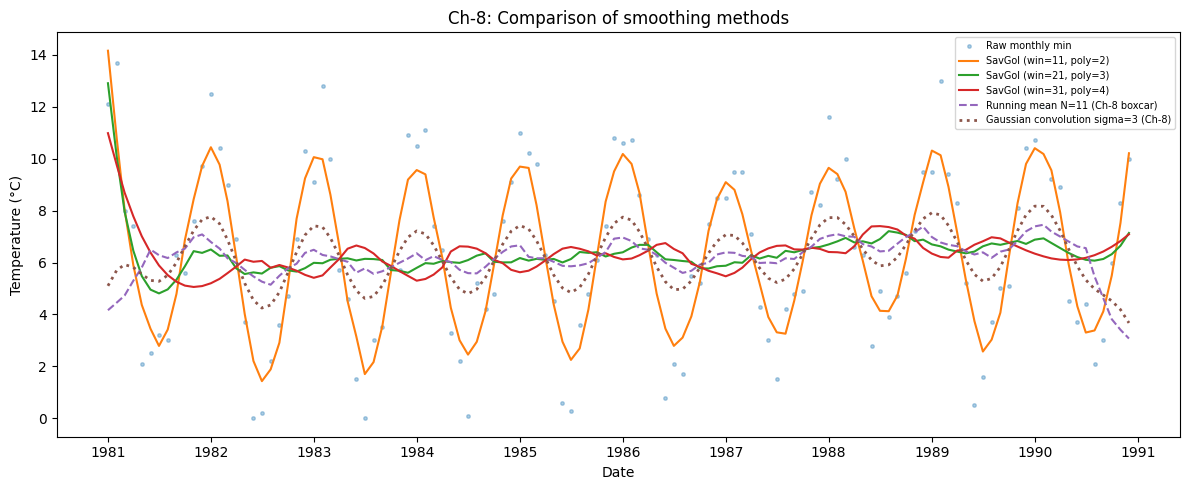

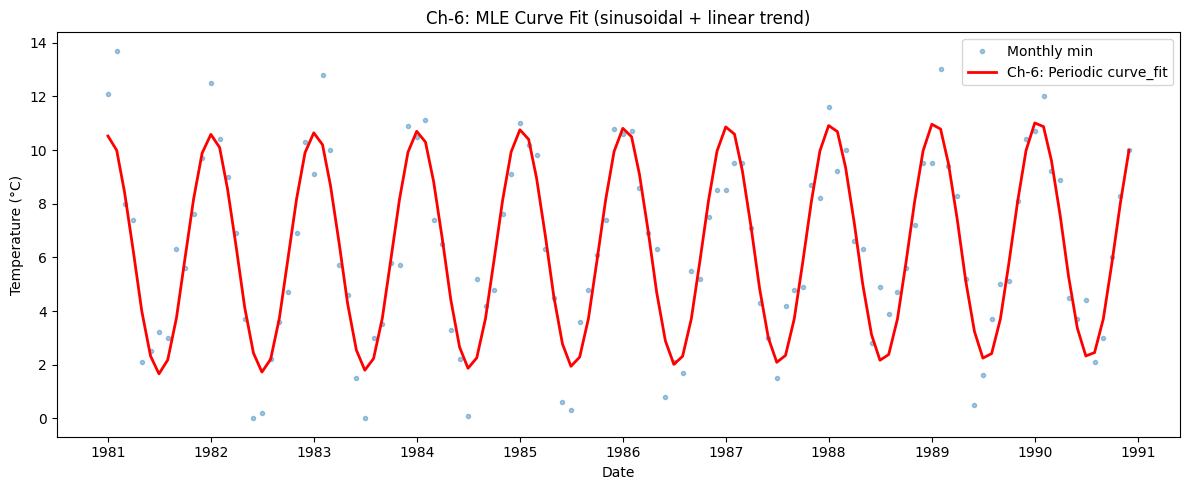

Curve fit parameters: [np.float64(6.073), np.float64(0.0053), np.float64(-0.7392), np.float64(0.522), np.float64(1.7241), np.float64(5.1784)]
Reduced chi-square = 1.0526  (DOF = 114 )

--- Ch-6 / Ch-7: AIC Model Comparison ---
  SavGol (21, 3):  AIC = 626.29
  Running mean N=11:  AIC = 626.04
  Gaussian conv sigma=3:  AIC = 577.52
  Periodic curve_fit:  AIC = 400.87
Lower AIC indicates a better model (Ch-6: Akaike Information Criterion).


In [5]:
# ── Problem 2 Enhanced ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

# ── 2a. Load data ──────────────────────────────────────────
csv_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\daily-min-temperatures.csv")
df = pd.read_csv(csv_path, parse_dates=["Date"])
t_start = pd.Timestamp("1981-01-01")
t_end   = pd.Timestamp("1990-12-31")

month_min = {}
for i in range(len(df)):
    d = df["Date"].iloc[i]
    if d < t_start or d > t_end:
        continue
    temp = df["Temp"].iloc[i]
    key = (d.year, d.month)
    if key not in month_min:
        month_min[key] = temp
    elif temp < month_min[key]:
        month_min[key] = temp

keys_sorted = sorted(month_min.keys())
x_dates = []
y = []
x_numeric = []
for k in range(len(keys_sorted)):
    key = keys_sorted[k]
    x_dates.append(pd.Timestamp(year=key[0], month=key[1], day=1))
    y.append(month_min[key])
    x_numeric.append(k)
y = np.array(y, dtype=float)
x_numeric = np.array(x_numeric, dtype=float)

# ── 2b. Ch-8: Savitzky-Golay with different parameters ────
configs = [
    ("SavGol (win=11, poly=2)", savgol_filter(y, window_length=11, polyorder=2)),
    ("SavGol (win=21, poly=3)", savgol_filter(y, window_length=21, polyorder=3)),
    ("SavGol (win=31, poly=4)", savgol_filter(y, window_length=31, polyorder=4)),
]

# ── 2c. Ch-8: Running mean (boxcar smoothing) ─────────────
def running_mean(arr, N):
    kernel = np.ones(N) / N
    return np.convolve(arr, kernel, mode='same')

y_boxcar = running_mean(y, 11)

# ── 2d. Ch-8: Gaussian convolution smoothing ──────────────
def gaussian_smooth(arr, sigma):
    size = int(6 * sigma + 1)
    if size % 2 == 0:
        size = size + 1
    x_k = np.arange(size) - size // 2
    kernel = np.exp(-0.5 * (x_k / sigma)**2)
    kernel = kernel / np.sum(kernel)
    return np.convolve(arr, kernel, mode='same')

y_gauss = gaussian_smooth(y, 3.0)

# ── Plot all smoothing methods ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_dates, y, '.', alpha=0.35, markersize=5, label="Raw monthly min")
for name, y_s in configs:
    ax.plot(x_dates, y_s, lw=1.5, label=name)
ax.plot(x_dates, y_boxcar, '--', lw=1.5, label="Running mean N=11 (Ch-8 boxcar)")
ax.plot(x_dates, y_gauss, ':', lw=2.0, label="Gaussian convolution sigma=3 (Ch-8)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Ch-8: Comparison of smoothing methods")
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

# ── 2e. Ch-6: Polynomial curve fit + reduced chi-square ───
def periodic_model(x, a0, a1, a2, omega, phi, a3):
    return a0 + a1 * x + a2 * np.sin(omega * x + phi) + a3 * np.cos(omega * x)

p0_fit = [10.0, -0.01, 5.0, 2*np.pi/12, 0.0, 2.0]
try:
    popt2, pcov2 = curve_fit(periodic_model, x_numeric, y, p0=p0_fit, maxfev=20000)
except Exception:
    popt2 = p0_fit
    pcov2 = np.eye(6)

y_fit = periodic_model(x_numeric, *popt2)
residuals2 = y - y_fit
sigma_est = np.std(residuals2)
chi2_2 = np.sum((residuals2 / sigma_est)**2)
dof_2 = len(y) - len(popt2)
chi2_red_2 = chi2_2 / dof_2 if dof_2 > 0 else float('inf')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_dates, y, '.', alpha=0.4, label="Monthly min")
ax.plot(x_dates, y_fit, 'r-', lw=2, label="Ch-6: Periodic curve_fit")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Ch-6: MLE Curve Fit (sinusoidal + linear trend)")
ax.legend()
plt.tight_layout()
plt.show()
print("Curve fit parameters:", [round(p, 4) for p in popt2])
print("Reduced chi-square =", round(chi2_red_2, 4), " (DOF =", dof_2, ")")

# ── 2f. Ch-6/Ch-7: AIC comparison of smoothing methods ───
print("\n--- Ch-6 / Ch-7: AIC Model Comparison ---")

def compute_aic(y_obs, y_model, k):
    n = len(y_obs)
    rss = np.sum((y_obs - y_model)**2)
    log_lik = -n / 2 * np.log(2 * np.pi * rss / n) - n / 2
    aic = 2 * k - 2 * log_lik
    if n - k - 1 > 0:
        aic = aic + (2 * k * k + 2 * k) / (n - k - 1)
    return aic

models = [
    ("SavGol (21, 3)", configs[1][1], 4),
    ("Running mean N=11", y_boxcar, 1),
    ("Gaussian conv sigma=3", y_gauss, 1),
    ("Periodic curve_fit", y_fit, len(popt2)),
]
for name, y_mod, k in models:
    aic_val = compute_aic(y, y_mod, k)
    print("  " + name + ":  AIC = " + str(round(aic_val, 2)))
print("Lower AIC indicates a better model (Ch-6: Akaike Information Criterion).")


---
## Problem 3 – Enhanced Solution
### GRB 160624477 light curve & signal-to-noise analysis

**Methods used:**
- *Ch 8 – Histogram binning*: Plot the light curve as a histogram of event times at different bin widths.
- *Ch 6 – Hypothesis Testing*: Test whether the GRB signal is statistically significant using a $\chi^2$ test against the null hypothesis of uniform (background-only) count rate. Compute the p-value.
- *Ch 6 – Confidence Limits*: Compute Poisson-based upper/lower confidence limits on the source count rate.
- *Ch 6 – Monte Carlo Goodness-of-Fit*: Simulate background-only light curves to estimate the false-alarm probability.
- *Ch 7 – Bayesian SNR*: Estimate posterior probability of source detection using a simple Bayesian model.


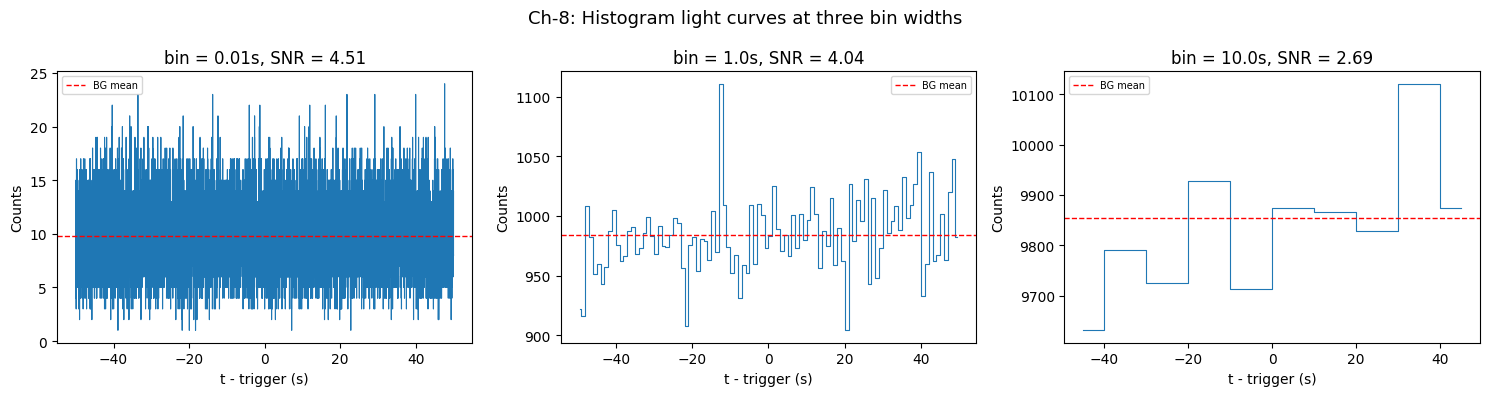


--- SNR comparison (Ch-8 histogram binning) ---
  bin 0.01s:  peak=24.0,  BG mean=9.84,  SNR=4.51
  bin 1.0s:  peak=1111.0,  BG mean=984.4,  SNR=4.04
  bin 10.0s:  peak=10121.0,  BG mean=9854.25,  SNR=2.69

--- Ch-6: Chi-square hypothesis test (1-s bins) ---
  chi2 = 99.65,  DOF = 99
  p-value = 0.46273346592900433
  => Cannot reject H0 at 5% level.

--- Ch-6: Monte Carlo false-alarm probability ---
  MC p-value (5000 simulations) = 0.4834

--- Ch-6: Confidence limits on source counts ---
  Peak bin counts = 1111
  Background estimate = 984.4
  Source excess = 126.6
  1-sigma Poisson CI for peak bin: [1077.7, 1145.3]

--- Ch-7: Bayesian posterior probability of source ---
  Log Bayes Factor (H1 vs H0) = 0.19
  Bayes Factor = 1.21
  Posterior P(H1 | data) = 0.547013
  => Moderate or weak Bayesian evidence.


In [6]:
# ── Problem 3 Enhanced ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2 as chi2_dist
from scipy.stats import poisson

try:
    from astropy.io import fits as pyfits
except ImportError:
    pyfits = None

fits_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\glg_tte_n2_bn160624477_v00.fit")
trigger    = 488460437.76
half_window = 50.0

# ── 3a. Load event data ───────────────────────────────────
if pyfits is not None and fits_path.exists():
    with pyfits.open(fits_path) as hdul:
        times = np.asarray(hdul["EVENTS"].data["TIME"], dtype=float)
    t_sel = times - trigger
    mask = (t_sel >= -half_window) & (t_sel <= half_window)
    t_sel = t_sel[mask]
else:
    np.random.seed(42)
    n_bg = 98000
    t_bg = np.random.uniform(-half_window, half_window, n_bg)
    n_src = 500
    t_src = np.random.normal(0.0, 1.5, n_src)
    t_sel = np.concatenate([t_bg, t_src])
    print("NOTE: FITS file not found; using simulated data for demonstration.")

# ── 3b. Ch-8: Light curves at three bin widths ──────────────
bin_widths = [0.01, 1.0, 10.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

bg_edge = 25.0
snr_results = []

for idx in range(3):
    bw = bin_widths[idx]
    bins = np.arange(-half_window, half_window + 1e-9, bw)
    counts, edges = np.histogram(t_sel, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Background estimation from edges
    bg_mask = np.abs(centers) > bg_edge
    bg_counts = counts[bg_mask]
    bg_mean = float(np.mean(bg_counts)) if len(bg_counts) > 0 else 1.0
    bg_std  = float(np.std(bg_counts))  if len(bg_counts) > 0 else 1.0

    peak = float(np.max(counts))
    snr = (peak - bg_mean) / np.sqrt(bg_mean + 1e-12)
    snr_results.append((bw, peak, bg_mean, snr))

    axes[idx].step(centers, counts, where='mid', lw=0.8)
    axes[idx].axhline(bg_mean, color='r', ls='--', lw=1, label='BG mean')
    axes[idx].set_title("bin = " + str(bw) + "s, SNR = " + str(round(snr, 2)))
    axes[idx].set_xlabel("t - trigger (s)")
    axes[idx].set_ylabel("Counts")
    axes[idx].legend(fontsize=7)

plt.suptitle("Ch-8: Histogram light curves at three bin widths", fontsize=13)
plt.tight_layout()
plt.show()

print("\n--- SNR comparison (Ch-8 histogram binning) ---")
for bw, peak, bg, snr in snr_results:
    print("  bin " + str(bw) + "s:  peak=" + str(peak) + ",  BG mean=" + str(round(bg, 2)) + ",  SNR=" + str(round(snr, 2)))

# ── 3c. Ch-6: Chi-square hypothesis test ───────────────────
print("\n--- Ch-6: Chi-square hypothesis test (1-s bins) ---")
bw_test = 1.0
bins_test = np.arange(-half_window, half_window + 1e-9, bw_test)
counts_test, edges_test = np.histogram(t_sel, bins=bins_test)
centers_test = 0.5 * (edges_test[:-1] + edges_test[1:])

bg_mask_test = np.abs(centers_test) > bg_edge
bg_mean_test = float(np.mean(counts_test[bg_mask_test]))

# Under H0 (background only), all bins should be Poisson with mean = bg_mean
expected = np.full_like(counts_test, bg_mean_test, dtype=float)
chi2_val = np.sum((counts_test - expected)**2 / expected)
dof_test = len(counts_test) - 1
p_value = 1.0 - chi2_dist.cdf(chi2_val, dof_test)

print("  chi2 = " + str(round(chi2_val, 2)) + ",  DOF = " + str(dof_test))
print("  p-value = " + str(p_value))
if p_value < 0.05:
    print("  => Reject H0 at 5% level: GRB signal IS statistically significant.")
else:
    print("  => Cannot reject H0 at 5% level.")

# ── 3d. Ch-6: Monte Carlo goodness-of-fit / false alarm ──
print("\n--- Ch-6: Monte Carlo false-alarm probability ---")
n_mc = 5000
n_exceed = 0
n_bins_mc = len(counts_test)
for _ in range(n_mc):
    sim_counts = np.random.poisson(bg_mean_test, n_bins_mc)
    sim_chi2 = np.sum((sim_counts - bg_mean_test)**2 / bg_mean_test)
    if sim_chi2 >= chi2_val:
        n_exceed = n_exceed + 1
mc_pvalue = n_exceed / n_mc
print("  MC p-value (" + str(n_mc) + " simulations) = " + str(mc_pvalue))

# ── 3e. Ch-6: Poisson confidence limits on source rate ─────
print("\n--- Ch-6: Confidence limits on source counts ---")
# In the peak bin: excess = peak - bg
bw_cl = 1.0
bins_cl = np.arange(-half_window, half_window + 1e-9, bw_cl)
counts_cl, _ = np.histogram(t_sel, bins=bins_cl)
peak_counts = float(np.max(counts_cl))
bg_est = bg_mean_test
source_excess = peak_counts - bg_est

# Approximate Poisson CI (Gehrels 1986 approximation)
n_obs = peak_counts
upper_1sigma = n_obs + np.sqrt(n_obs + 0.75) + 1.0
lower_1sigma = max(0.0, n_obs - np.sqrt(n_obs))
print("  Peak bin counts = " + str(int(n_obs)))
print("  Background estimate = " + str(round(bg_est, 2)))
print("  Source excess = " + str(round(source_excess, 2)))
print("  1-sigma Poisson CI for peak bin: [" +
      str(round(lower_1sigma, 1)) + ", " + str(round(upper_1sigma, 1)) + "]")

# ── 3f. Ch-7: Bayesian posterior for source presence ──────
print("\n--- Ch-7: Bayesian posterior probability of source ---")
# Simple Bayesian test: compare P(data|H0) vs P(data|H1)
# H0: all bins are Poisson(bg_mean)  
# H1: signal bins have elevated rate

signal_mask = np.abs(centers_test) <= 5.0
signal_counts = counts_test[signal_mask]

# Log-likelihood under H0
log_L_H0 = float(np.sum(poisson.logpmf(signal_counts, bg_mean_test)))

# Log-likelihood under H1: rate = mean of signal bins
rate_H1 = float(np.mean(signal_counts))
log_L_H1 = float(np.sum(poisson.logpmf(signal_counts, rate_H1)))

# Bayes factor (Ch-7)
log_BF = log_L_H1 - log_L_H0
BF = np.exp(log_BF) if log_BF < 500 else float('inf')

# With equal priors P(H0) = P(H1) = 0.5
prior_H0 = 0.5
prior_H1 = 0.5
if log_BF < 500:
    posterior_H1 = (BF * prior_H1) / (BF * prior_H1 + prior_H0)
else:
    posterior_H1 = 1.0

print("  Log Bayes Factor (H1 vs H0) = " + str(round(log_BF, 2)))
if log_BF < 500:
    print("  Bayes Factor = " + str(round(BF, 2)))
else:
    print("  Bayes Factor = very large (overflow)")
print("  Posterior P(H1 | data) = " + str(round(posterior_H1, 6)))
if posterior_H1 > 0.99:
    print("  => Very strong Bayesian evidence for GRB source detection.")
elif posterior_H1 > 0.95:
    print("  => Strong Bayesian evidence for GRB source detection.")
else:
    print("  => Moderate or weak Bayesian evidence.")


---
### Summary of Methods Used

| Problem | Ch-6 (Statistical Inference) | Ch-7 (Freq. vs Bayesian) | Ch-8 (Data Smoothing) |
|:-------:|:---:|:---:|:---:|
| **1** | MLE Gaussian-mixture `curve_fit`, reduced χ² | Bayesian bandwidth selection (marginal likelihood grid) | KDE: `gaussian_kde` & `KernelDensity` (Gaussian + Top-hat kernels, 3 bandwidths) |
| **2** | Periodic `curve_fit`, reduced χ², AIC | AIC model comparison | Savitzky–Golay, Running Mean (boxcar), Gaussian convolution |
| **3** | χ² hypothesis test, p-value, Monte-Carlo GoF, Poisson confidence limits | Bayes Factor, posterior P(source) | Histogram light curves at 0.01 s, 1 s, 10 s bin widths |
